<a href="https://colab.research.google.com/github/danielqhtruong/MATH497_Research_TDA/blob/main/Notebook1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Topological Data Analyst

By Quan Truong

In [2]:
import gudhi as gd
import geopandas as gpd
import numpy as np
import random
import matplotlib.pyplot as plt


### La County

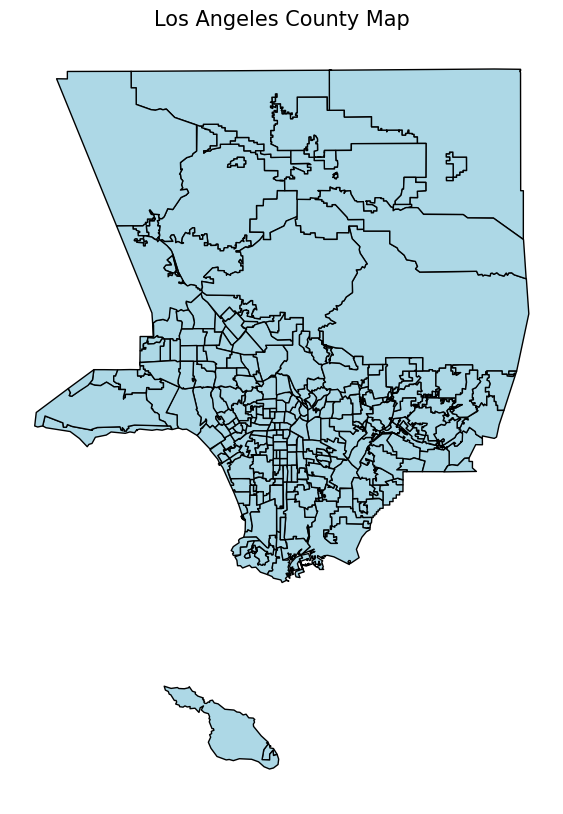

In [15]:
### LA County
# Load GeoJSON file
gdf = gpd.read_file("data/la_county.geojson")

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
gdf.plot(ax=ax, edgecolor='black', color='lightblue')

# Styling
ax.set_title("Los Angeles County Map", fontsize=15)
ax.set_axis_off()

plt.show()
fig.savefig("figures/la_county_map.png")

## Persistent Homology

### Fire Stations

In [2]:
# Load fire stations
FD_Location = gpd.read_file("data/all_stations.geojson")

# Extract coordinates
coords = np.array([
    [point.x, point.y] for point in FD_Location.geometry
])

print(coords.shape)

(412, 2)


In [3]:
FD_Location.head()

,address,city,zip,department,stanum,geometry
0,2759 Rowena Avenue,Los Angeles,90039,LAFD,56,POINT (-118.26386 34.10765)
1,135 South Fair Oaks Avenue,Pasadena,91105,Pasadena Fire Department,31,POINT (-118.15073 34.14318)
2,3361 Palo Verde Avenue,Long Beach,90808,Long Beach Fire Department,18,POINT (-118.10821 33.81822)
3,540 Pier Avenue,Hermosa Beach,90254,Hermosa Beach Fire Department,NaN,POINT (-118.39593 33.86418)
4,21050 Burbank Boulevard,Woodland Hills,91367,LAFD,84,POINT (-118.59148 34.17294)


In [4]:
# Project to UTM (meters) – appropriate for Los Angeles
gdf = FD_Location.to_crs(epsg=32611)

coords = np.array([
    [point.x, point.y] for point in gdf.geometry
])

In [5]:
num_landmarks = int(0.3 * len(coords))
landmark_indices = random.sample(range(len(coords)), num_landmarks)

landmarks = coords[landmark_indices]
witnesses = coords

In [6]:
wc = gd.EuclideanWitnessComplex(
    witnesses=witnesses,
    landmarks=landmarks
)  # Create witness complex

# Create simplex tree
simplex_tree = wc.create_simplex_tree(
    max_alpha_square=50000000  # scale parameter (adjust!)
)

/opt/miniconda3/lib/python3.13/site-packages/gudhi/persistence_graphical_tools.py:129: UserWarning: usetex mode requires TeX.
  warnings.warn("usetex mode requires TeX.")


<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

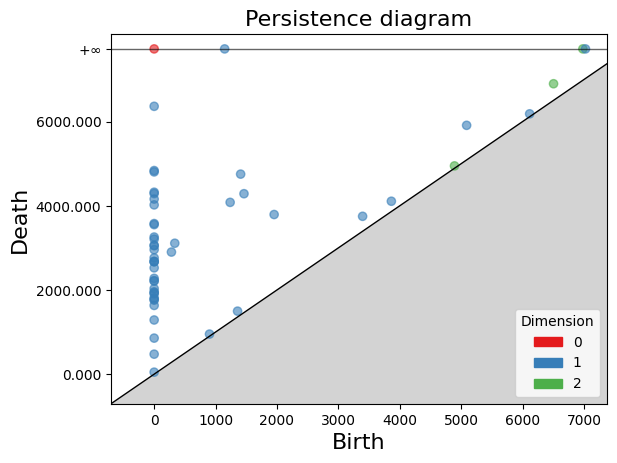

In [7]:
simplex_tree.compute_persistence()

diag = simplex_tree.persistence()
# convert alpha^2 to alpha
diag = [(dim, (np.sqrt(b), np.sqrt(d))) for dim, (b, d) in diag]

gd.plot_persistence_diagram(diag)

In [8]:
from mpl_toolkits.mplot3d import Axes3D

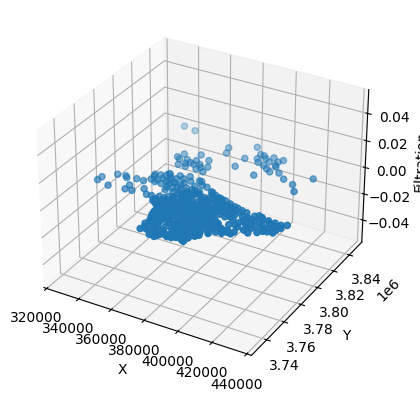

In [9]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# coords = projected fire station coordinates
x = coords[:, 0]
y = coords[:, 1]

# Use alpha values as z-axis
z = np.zeros_like(x)

ax.scatter(x, y, z)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Filtration")
plt.show()

### Hospital

In [12]:
# Load hospitals
Hospital_Location = gpd.read_file("data/hospitals.geojson")

# Extract coordinates
coords = np.array([
    [point.x, point.y] for point in Hospital_Location.geometry
])

print(coords.shape)

(165, 2)


In [13]:
Hospital_Location.head()

,objectid,name,geometry
0,9,Verdugo Hills Hospital,POINT (-118.21602 34.20453)
1,11,Barlow Respiratory Hospital - Los Angeles (Mai...,POINT (-118.24831 34.07569)
2,20,Glendora Community Hospital,POINT (-117.86507 34.12731)
3,25,Providence Little Company Of Mary Medical Cent...,POINT (-118.35711 33.83863)
4,35,Glendale Memorial Hospital And Health Center,POINT (-118.25744 34.12806)


In [17]:
num_landmarks_hos = int(0.3 * len(coords_hos))
landmark_indices_hos = random.sample(range(len(coords_hos)), num_landmarks_hos)

landmarks_hos = coords_hos[landmark_indices_hos]
witnesses_hos = coords_hos

In [20]:
wc = gd.EuclideanWitnessComplex(
    witnesses=witnesses_hos,
    landmarks=landmarks_hos
)  # Create witness complex

# Create simplex tree
simplex_tree_hos = wc.create_simplex_tree(
    max_alpha_square=50000000  # scale parameter (adjust!)
)

<Axes: title={'center': 'Persistence diagram'}, xlabel='Birth', ylabel='Death'>

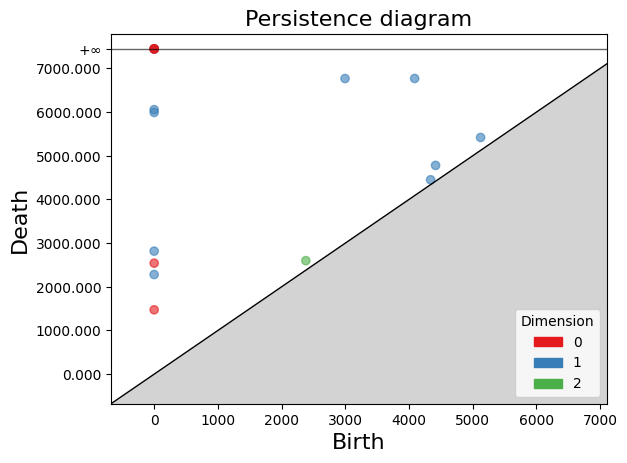

In [21]:
simplex_tree_hos.compute_persistence()

diag = simplex_tree_hos.persistence()
# convert alpha^2 to alpha
diag = [(dim, (np.sqrt(b), np.sqrt(d))) for dim, (b, d) in diag]

gd.plot_persistence_diagram(diag)

## Mapper Algorithm ##